In [1]:
%matplotlib widget
from easydynamics.analysis import Analysis


from easydynamics.sample import Gaussian
from easydynamics.sample import Lorentzian
from easydynamics.sample import Polynomial
from easydynamics.sample import SampleModel
from easydynamics.sample import DeltaFunction

from easydynamics.experiment  import Experiment

from easydynamics.job import Job
from easydynamics.experiment  import Data


In [2]:
MyJob= Job(name='Vanadium sample')

theory= SampleModel('Vanadium Model')
theory.add_component(Gaussian(width=0.5e-3,area=5e-5,name='Res Gauss'))
theory.add_component(Lorentzian(width=2e-3, area=2e-6,name='Res Lorz'))

MyJob.set_theory(theory)

experiment=Experiment()

background=SampleModel()
background.add_component(Polynomial(coefficients=[1e-3],name='BG'))

MyJob.set_background_model(background)

data=Data()
data.append(data.load_example_vanadium_data_1d())

experiment.set_data(data)

MyJob.set_experiment(experiment)


analysis=Analysis('Vanadium Analysis')

# analysis.set_background_model(background)

# analysis.set_resolution_model(None)

MyJob.append_analysis(analysis)

In [3]:
theory.components['Res Gauss'].get_parameters()

[<Parameter 'Res Gauss area': 5.000e-05 meV, bounds=[0.0:inf]>,
 <Parameter 'Res Gauss center': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Res Gauss width': 0.0005 meV, bounds=[0.0:inf]>]

In [4]:
theory.components['Res Gauss'].set_parameter_value('area', 0.2)
theory.components['Res Gauss'].set_parameter_bounds('area', min=0.1,max=10)
theory.components['Res Gauss'].fix_parameter('area')

theory.components['Res Gauss'].get_parameters()

[<Parameter 'Res Gauss area': 0.2000 meV (fixed), bounds=[0.1:10.0]>,
 <Parameter 'Res Gauss center': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Res Gauss width': 0.0005 meV, bounds=[0.0:inf]>]

In [5]:
MyJob.fit()

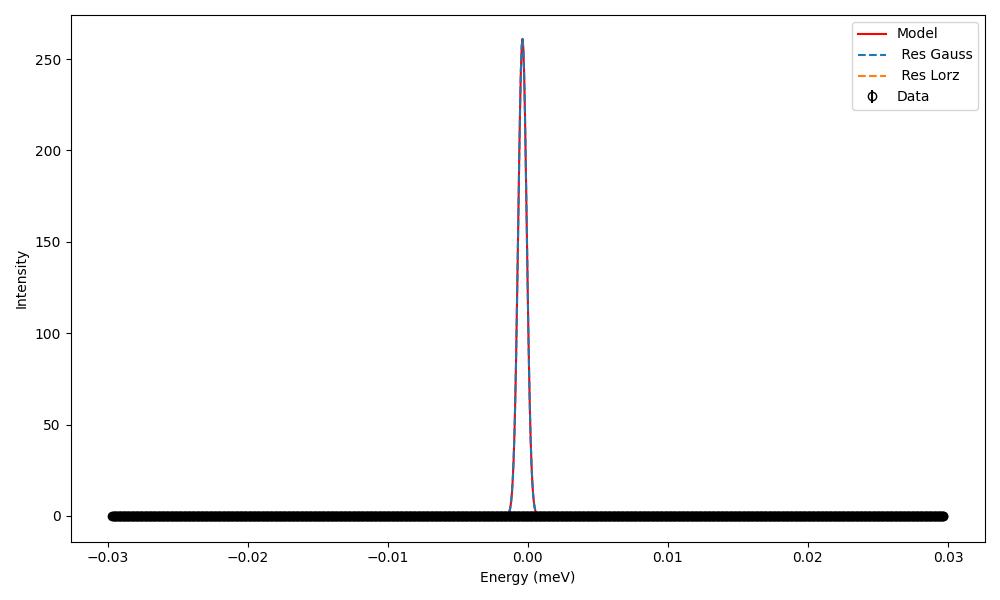

(0.0, 0.07)

In [6]:
fig=MyJob.analysis[-1].plot_data_and_model(plot_individual_components=True)

fig.axes[0].set_xlim(-0.02, 0.02)
fig.axes[0].set_ylim(0, 0.07)

In [7]:
pars=MyJob.analysis[-1].get_parameters()
pars

[<Parameter 'Res Gauss area': 0.2000 meV (fixed), bounds=[0.1:10.0]>,
 <Parameter 'Res Gauss center': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Res Gauss width': 0.0003 ± 0.0000 meV, bounds=[0.0:inf]>,
 <Parameter 'Res Lorz area': 0.0278 ± 143207876.6380 meV, bounds=[0.0:inf]>,
 <Parameter 'Res Lorz center': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Res Lorz width': 1.167e+05 ± 6.006e+14 meV, bounds=[0.0:inf]>,
 <Parameter 'offset': -0.0004 ± 0.0000 meV, bounds=[-inf:inf]>]

In [8]:
DataJob= Job(name='Sample')

Newtheory= SampleModel('Model')
Newtheory.add_component(DeltaFunction(area=0.01e-3,name='Delta'))
Newtheory.add_component(Lorentzian(width=2e-3, area=5e-6,name='Lorentzian'))

DataJob.set_theory(Newtheory)

Newexperiment=Experiment('Experiment')

Newbackground=SampleModel('Background')
Newbackground.add_component(Polynomial(coefficients=[1e-3],name='BG'))


# res=SampleModel('Resolution')
resolution=MyJob._theory.copy()
resolution.fix_all_parameters()

              


newdata=Data('Data')
newdata.append(newdata.load_example_data_1d())

Newexperiment.set_data(newdata)

DataJob.set_experiment(Newexperiment)


analysis=Analysis('Analysis')
analysis.set_background_model(Newbackground)

analysis.set_resolution_model(resolution)
DataJob.append_analysis(analysis)





In [9]:
print(DataJob._analysis_meta)

{'dims': (), 'sizes': {}}


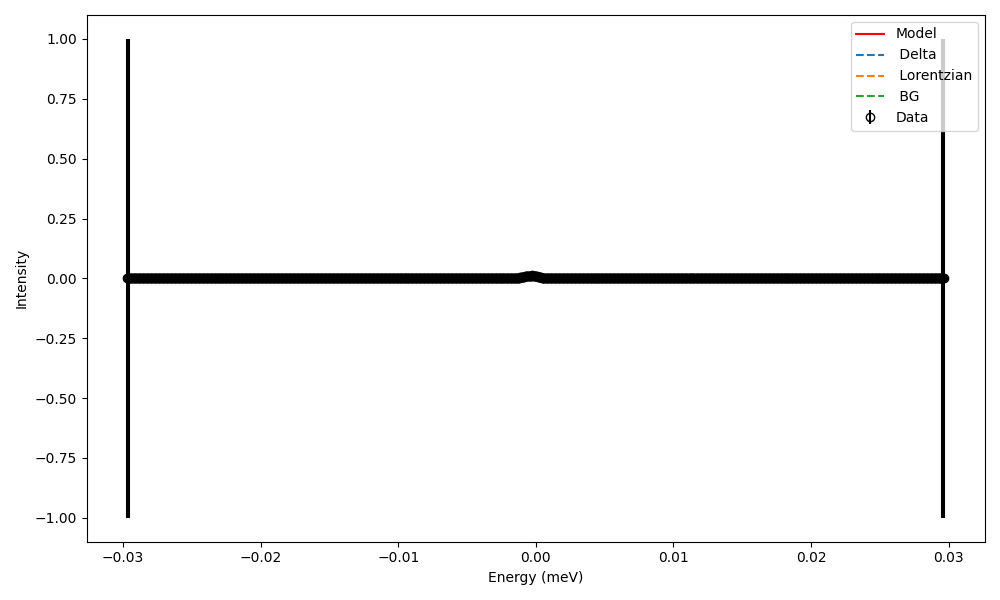

(0.0, 0.015)

In [10]:
fig=DataJob.analysis[-1].plot_data_and_model(plot_individual_components=True)

fig.axes[0].set_xlim(-0.02, 0.02)
fig.axes[0].set_ylim(0, 0.015)

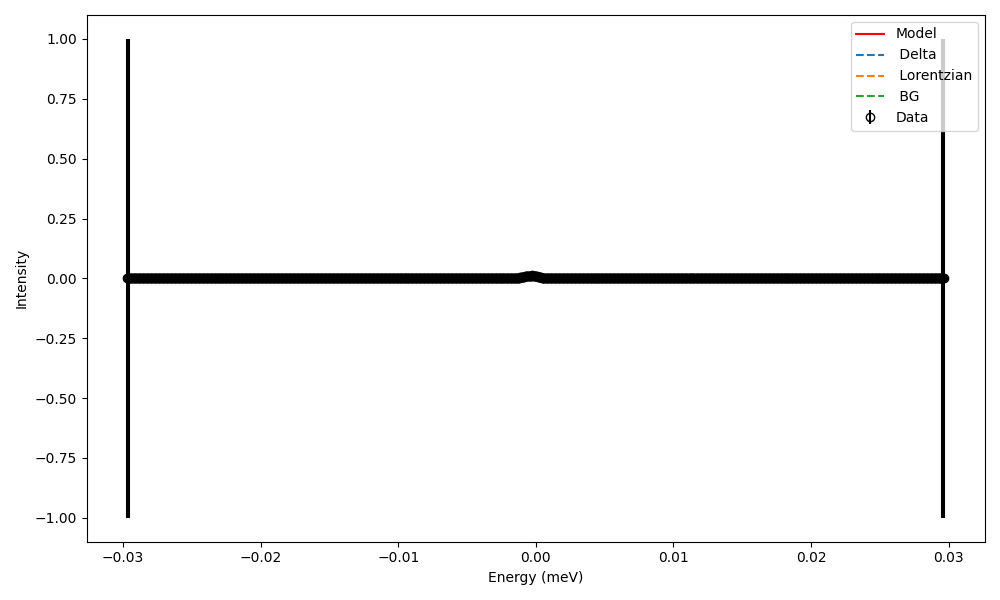

(0.0, 0.015)

In [11]:
DataJob.fit()
fig=DataJob.analysis[-1].plot_data_and_model(plot_individual_components=True)

fig.axes[0].set_xlim(-0.029, 0.029)
fig.axes[0].set_ylim(0, 0.015)


In [12]:
DataJob.analysis[-1].get_fit_parameters()

[<Parameter 'Delta area': 1.046e-05 ± 4.957e-07 meV, bounds=[0.0:inf]>,
 <Parameter 'Lorentzian area': 1.736e-05 ± 3.148e-07 meV, bounds=[0.0:inf]>,
 <Parameter 'Lorentzian width': 0.0024 ± 0.0001 meV, bounds=[0.0:inf]>,
 <Parameter 'BG_c0': 0.0002 ± 0.0000, bounds=[-inf:inf]>,
 <Parameter 'offset': -0.0004 ± 0.0000 meV, bounds=[-inf:inf]>]

In [13]:
DataJob.analysis[-1].get_parameters()

[<Parameter 'Delta area': 1.046e-05 ± 4.957e-07 meV, bounds=[0.0:inf]>,
 <Parameter 'Delta center': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Lorentzian area': 1.736e-05 ± 3.148e-07 meV, bounds=[0.0:inf]>,
 <Parameter 'Lorentzian center': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Lorentzian width': 0.0024 ± 0.0001 meV, bounds=[0.0:inf]>,
 <Parameter 'Res Gauss area': 0.8779 meV (fixed), bounds=[0.0:inf]>,
 <Parameter 'Res Gauss center': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Res Gauss width': 0.0003 meV (fixed), bounds=[0.0:inf]>,
 <Parameter 'Res Lorz area': 0.1221 meV (fixed), bounds=[0.0:inf]>,
 <Parameter 'Res Lorz center': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Res Lorz width': 1.167e+05 meV (fixed), bounds=[0.0:inf]>,
 <Parameter 'BG_c0': 0.0002 ± 0.0000, bounds=[-inf:inf]>,
 <Parameter 'offset': -0.0004 ± 0.0000 meV, bounds=[-inf:inf]>]